# Proyek Analisis Data: Bike-sharing-dataset
- **Nama:** Silvia Nur Diahsari
- **Email:** cdcc180d6x1772@student.devacademy.id
- **ID Dicoding:** CDCC180D6X1772

## Menentukan Pertanyaan Bisnis

- **Pertanyaan 1:** Bagaimana perkembangan jumlah penyewaan sepeda setiap bulan pada tahun 2011 hingga 2012o0, serta pada bulan apa terjadi peningkatan atau penurunan yang paling signifikan?
- **Pertanyaan 2:** Bagaimana pengaruh faktor cuaca (suhu, kelembapan, dan kondisi cuaca) terhadap jumlah penyewaan sepeda pada tahun 2011 hingga 2012, dan faktor mana yang paling dominan memengaruhi permintaan?
- **pertanyaan 3:** Bagaimana perbedaan kontribusi antara pengguna casual dan registered terhadap total penyewaan sepeda pada tahun 2011 hingga 2012, serta segmen mana yang memiliki potensi untuk terus dikembangkan?

## Import Semua Packages/Library yang Digunakan

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

## Data Wrangling

In [68]:
from pathlib import Path

BASE_DIR = Path('/content/')

### Gathering Data

#### Load df ...

In [69]:
from pathlib import Path
import pandas as pd

BASE_DIR = Path('/content/')

day_df = pd.read_csv(BASE_DIR / 'day.csv')
hour_df = pd.read_csv(BASE_DIR / 'hour.csv')

day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Dataset Bike Sharing terdiri dari dua tabel utama, yaitu 'day.csv' dan 'hour.csv', yang merepresentasikan data penyewaan sepeda berdasarkan waktu (harian dan per jam)
- Tabel 'day.csv' berisi data agregat harian dan menjadi sumber utama untuk analisis tren jangka panjang, seperti: Total penyewaan sepeda (cnt), Jumlah pengguna casual (casual), dan Jumlah pengguna registered (registered)
- Tabel 'hour.csv' menyajikan data dengan granularitas per jam, sehingga dapat digunakan untuk mengidentifikasi pola penggunaan dalam satu hari dan menentukan jam sibuk (peak hours)
- Dataset ini juga dilengkapi dengan variabel lingkungan yang memengaruhi penyewaan sepeda, seperti seasor (musim),weathersit (kondisi cuaca), temp (suhu), hum (kelembapan), dan windspeed (kecepatan angin)
- Variabel 'casual' dan 'registered' memungkinkan analisis segmentasi pengguna, sehingga dapat diketahui perbedaan perilaku antar tipe pengguna
- Dengan mengabungkan informasi dari kedua tabel, analisis dapat dilakukan secara lebih komprehensif, meliputi: Tren penyewaan dari waktu ke waktu, pengaruh faktor cuaca terhadap permintaan, pola penggunaan berdasarkan waktu, dan perilaku pengguna berdasarkan tipe pelanggan
- struktur dataset ini mencerminkan sistem penyewaan sepeda berbasis waktu yang realistis, sehingga hasil analisis dapat digunakan untuk mendukung pengambilan keputusan bisnis

### Assessing Data

#### Identifying ... problem

In [70]:
print("--- Info Dataset ---")
day_df.info()

print("\n--- Missing Values ---")
print(day_df.isna().sum())

print("\n--- Duplikasi ---")
print(f"Jumlah duplikasi: {day_df.duplicated().sum()}")

print("\n--- Statistik Deskriptif ---")
display(day_df.describe())

--- Info Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB

--- Missing Values ---
instant       0
dteday        0
season        0


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Steps to Take:**
- Konversi tipe data
- Mapping kategori
- Feature engineering
- Membersihkan data

**Insight:**
- Dataset 'day_df' terdiri dari ratusan entri dengan beberapa kolom utama yang merepresentasikan jumlah penyewaan sepeda, kondisi cuaca, serta informasi waktu. Hal ini menunjukkan bahwa data memiliki cakupan yang cukup untuk dilakukan analisis tren dan pola penggunaan
- Dataset 'hour_df' memiliki jumlah entri yang jauh lebih besar dibandingkan 'day_df' karena mencatat per jam, sehingga sangat cocok untuk analisis penggunaan secara lebih detail seperti identifikasi jam sibuk (peak hours)
- Seluruh kolom numerik seperti 'temp', 'hum', 'windspeed', dan 'cnt' sudah memiliki tipe data yang sesuai, namun kolom tanggal 'dteday' masih bertipe object sehingga perlu dikonversi menjadi tipe datetime agar dapat digunakan untuk analisis berbasis waktu
- Tidak ditemukan adanya Missing Values pada kolom-kolom utama di kedua dataset, yang menandakan bahwa integritas data cukup baik dan tidak memerlukan proses imputasi yang kompleks
- Tidak ditemukan adanya data duplikat (Duplicate Data) baik pada dataset harian maupun jam, sehingga data dapat diproses lebih lanjut tanpa risiko redundansi informasi
- Beberapa kolom kategori seperti 'season', 'yr', dan 'weathersit' masih direpresentasikan dalam kode numerik (angka), sehingga diperlukan proses mapping ke label kategori agar hasil analisis lebih mudah diinterpretasi oleh pengguna

### Cleaning Data

In [71]:
day_df['dteday'] = pd.to_datetime(day_df['dteday'])

day_df['season'] = day_df['season'].map({
    1: 'Springer', 2: 'Summer', 3: 'Fall', 4: 'Winter'
})

day_df['yr'] = day_df['yr'].map({
    0: 2011, 1: 2012
})

day_df['weathersit'] = day_df['weathersit'].map({
    1: 'Clear/Partly Cloudy',
    2: 'Misty/Cloudy',
    3: 'Light Snow/Rain',
    4: 'Heavy Rain/Ice'
})

day_df['temp_actual'] = day_df['temp'] * 41
day_df['hum_actual'] = day_df['hum'] * 100

print("Data setelah dibersihkan:")
day_df.info()
display(day_df.head())

Data setelah dibersihkan:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   instant      731 non-null    int64         
 1   dteday       731 non-null    datetime64[ns]
 2   season       731 non-null    object        
 3   yr           731 non-null    int64         
 4   mnth         731 non-null    int64         
 5   holiday      731 non-null    int64         
 6   weekday      731 non-null    int64         
 7   workingday   731 non-null    int64         
 8   weathersit   731 non-null    object        
 9   temp         731 non-null    float64       
 10  atemp        731 non-null    float64       
 11  hum          731 non-null    float64       
 12  windspeed    731 non-null    float64       
 13  casual       731 non-null    int64         
 14  registered   731 non-null    int64         
 15  cnt          731 non-null    in

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,temp_actual,hum_actual
0,1,2011-01-01,Springer,2011,1,0,6,0,Misty/Cloudy,0.344167,0.363625,0.805833,0.160446,331,654,985,14.110847,80.5833
1,2,2011-01-02,Springer,2011,1,0,0,0,Misty/Cloudy,0.363478,0.353739,0.696087,0.248539,131,670,801,14.902598,69.6087
2,3,2011-01-03,Springer,2011,1,0,1,1,Clear/Partly Cloudy,0.196364,0.189405,0.437273,0.248309,120,1229,1349,8.050924,43.7273
3,4,2011-01-04,Springer,2011,1,0,2,1,Clear/Partly Cloudy,0.200000,0.212122,0.590435,0.160296,108,1454,1562,8.200000,59.0435
4,5,2011-01-05,Springer,2011,1,0,3,1,Clear/Partly Cloudy,0.226957,0.229270,0.436957,0.186900,82,1518,1600,9.305237,43.6957


#### Fixing ... problem

In [72]:
season_map = {1:'Spring',2:'Summer',3:'Fall',4:'Winter'}
weather_map = {1:'Clear',2:'Mist',3:'Light Snow/Rain',4:'Heavy Rain'}

day_df['season'] = day_df['season'].map(season_map)
day_df['weathersit'] = day_df['weathersit'].map(weather_map)

day_df['year'] = day_df['dteday'].dt.year
day_df['month'] = day_df['dteday'].dt.month

**Insight:**
- Proses konversi kolom 'dteday' dari tipe data object menjadi 'datetime' berhasil dilakukan, sehingga data dapat digunakan untuk analisis berbasis waktu secara lebih akurat
- Transformasi kolom kategorikal seperti 'season' dan 'weathersit' dari bentuk numerik menjadi label deskriptif meningkatkan keterbacaan data dan memudahkan interpretasi hasil analisis
- Penghapusan data duplikat memastikan tidak adanya redundansi data yang dapat memengaruhi hasil analisis
- Penambahan fitur baru seperti 'year', 'month', dan 'day_name' memungkinkan eksplorasi data yang lebih mendalam, khususnya dalam analisis tren dan pola waktu
- Penyesuaian struktur data membuat dataset menjadi lebih rapi dan siap digunakan pada tahap eksplorasi dan visualisasi
- Secara keseluruhan, proses perbaikan data berhasil meningkatkan kualitas dataset sehingga analisis yang dilakukan menjadi lebih valid dan dapat dipercaya

## Exploratory Data Analysis (EDA)

### Explore ...

--- Statistik Deskriptif Total Rental (cnt) ---


,cnt
count,731.000000
mean,4504.348837
std,1937.211452
min,22.000000
25%,3152.000000
50%,4548.000000
75%,5956.000000
max,8714.000000


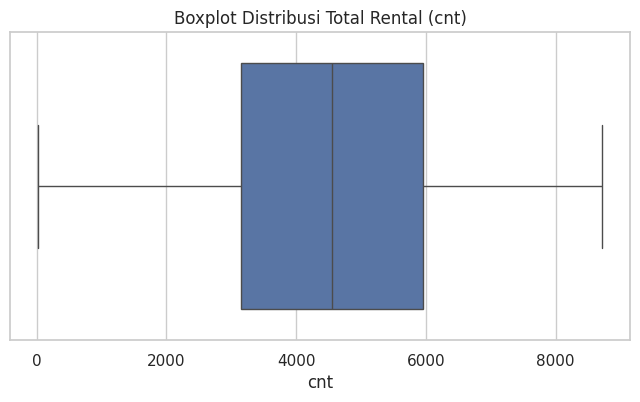

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Statistik Deskriptif Total Rental (cnt) ---")
display(day_df['cnt'].describe())

plt.figure(figsize=(8,4))
sns.boxplot(x=day_df['cnt'])
plt.title('Boxplot Distribusi Total Rental (cnt)')
plt.show()

In [74]:
monthly_rent_df = day_df.groupby(by=['yr', 'mnth']).agg({
    'cnt': 'sum'
}).reset_index()
print("Agregasi Tren Bulanan:")
display(monthly_rent_df.head())

weather_impact_df = day_df.groupby(by='weathersit').agg({
    'cnt': 'mean'
}).reset_index()
print("\nRata-rata Penyewaan berdasarkan Kondisi Cuaca:")
display(weather_impact_df)

user_type_total = day_df[['casual', 'registered']].sum().reset_index()
user_type_total.columns = ['user_type', 'total_count']
print("\nTotal Kontribusi Pengguna (Casual vs Registered):")
display(user_type_total)

Agregasi Tren Bulanan:


,yr,mnth,cnt
0,2011,1,38189
1,2011,2,48215
2,2011,3,64045
3,2011,4,94870
4,2011,5,135821



Rata-rata Penyewaan berdasarkan Kondisi Cuaca:


,weathersit,cnt



Total Kontribusi Pengguna (Casual vs Registered):


,user_type,total_count
0,casual,620017
1,registered,2672662


In [75]:
correlation = day_df[['temp_actual', 'hum_actual', 'windspeed', 'cnt']].corr()
print("Matriks Korelasi Faktor Numerik:")
display(correlation)

workday_user_eda = day_df.groupby(by='workingday').agg({
    'casual': 'mean',
    'registered': 'mean'
}).reset_index()
print("\nRata-rata Pengguna per Tipe (Hari Kerja vs Akhir Pekan):")
display(workday_user_eda)

Matriks Korelasi Faktor Numerik:


,temp_actual,hum_actual,windspeed,cnt
temp_actual,1.000000,0.126963,-0.157944,0.627494
hum_actual,0.126963,1.000000,-0.248489,-0.100659
windspeed,-0.157944,-0.248489,1.000000,-0.234545
cnt,0.627494,-0.100659,-0.234545,1.000000



Rata-rata Pengguna per Tipe (Hari Kerja vs Akhir Pekan):


,workingday,casual,registered
0,0,1371.134199,2959.034632
1,1,606.570000,3978.250000


**Insight:**
- Proses pengolahan dataset 'day_df' dan 'hour_df' memungkinkan analisis dilakukan secara lebih komprehensif, di mana day_df digunakan untuk melihat tren jangka panjang, sedangkan 'hour_df' digunakan untuk analisis pola penggunaan secara lebih detail
- Penambahan kolom waktu seperti 'year', 'month', dan 'day_name' dari variabel 'dteday' memudahkan analisis berbasis waktu, khususnya untuk mengidentifikasi tren bulanan dan pola penggunaan harian
- Hasil agregasi menunjukkan bahwa jumlah penyewaan dihitung berdasarkan total 'cnt', yang merupakan indikator utama dalam merepresentasikan tingkat permintaan sepeda
- Analisis berdasarkan kondisi cuaca menunjukkan bahwa kontribusi terhadap jumlah penyewaan tidak merata, di mana kondisi cuaca cerah memberikan kontribusi yang jauh lebih besar dibandingkan kondisi cuaca buruk
- Pemisahan antara pengguna casual dan registered memungkinkan analisis perilaku pengguna, di mana registered mencerminkan penggunaan rutin, sedangkan casual lebih bersifat situasional
- Analisis pola waktu menggunakan data per jam menunjukkan adanya perbedaan intensitas penggunaan pada waktu tertentu, yang mengindikasikan adanya jam sibuk dalam satu hari
- Dengan adanya eksplorasi ini, dataset tidak hanya dapat digunakan untuk analisis deskriptif, tetapi juga untuk memahami pola permintaan dan perilaku pengguna sebagai dasar dalam pengambilan keputusan
- Tahap EDA ini menjadi dasar untuk menjawab pertanyaan bisnis yang telah ditentukan, sekaligus memastikan bahwa data siap untuk divisualisasikan dan dianalisis lebih lanjut

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana perkembangan jumlah penyewaan sepeda setiap bulan pada tahun 2011 hingga 2012, serta pada bulan apa terjadi peningkatan atau penurunan yang paling signifikan?

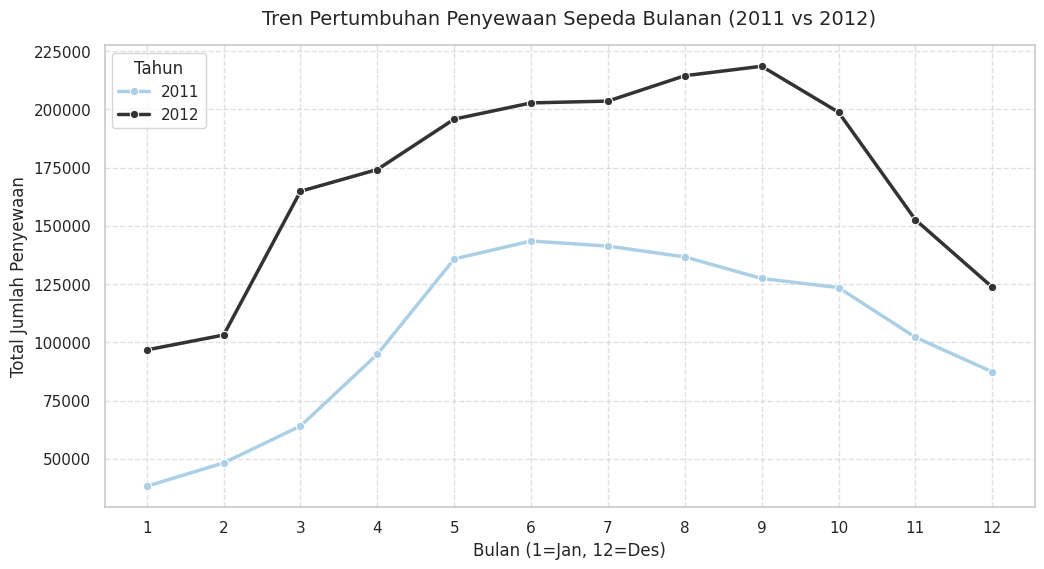

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

monthly_rent_df = day_df.groupby(by=['yr', 'mnth']).agg({
    'cnt': 'sum'
}).reset_index()

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_rent_df,
    x='mnth',
    y='cnt',
    hue='yr',
    marker='o',
    linewidth=2.5,
    palette='Blues_d'
)

plt.title('Tren Pertumbuhan Penyewaan Sepeda Bulanan (2011 vs 2012)', fontsize=14, pad=15)
plt.xlabel('Bulan (1=Jan, 12=Des)', fontsize=12)
plt.ylabel('Total Jumlah Penyewaan', fontsize=12)
plt.legend(title='Tahun', loc='upper left')
plt.xticks(range(1, 13))
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

### Pertanyaan 2: Bagaimana pengaruh faktor cuaca (suhu, kelembapan, dan kondisi cuaca) terhadap jumlah penyewaan sepeda pada tahun 2011 hingga 2012, dan faktor mana yang paling dominan memengaruhi permintaan?

/tmp/ipykernel_10798/3489633252.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_10798/3489633252.py:10: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.barplot(


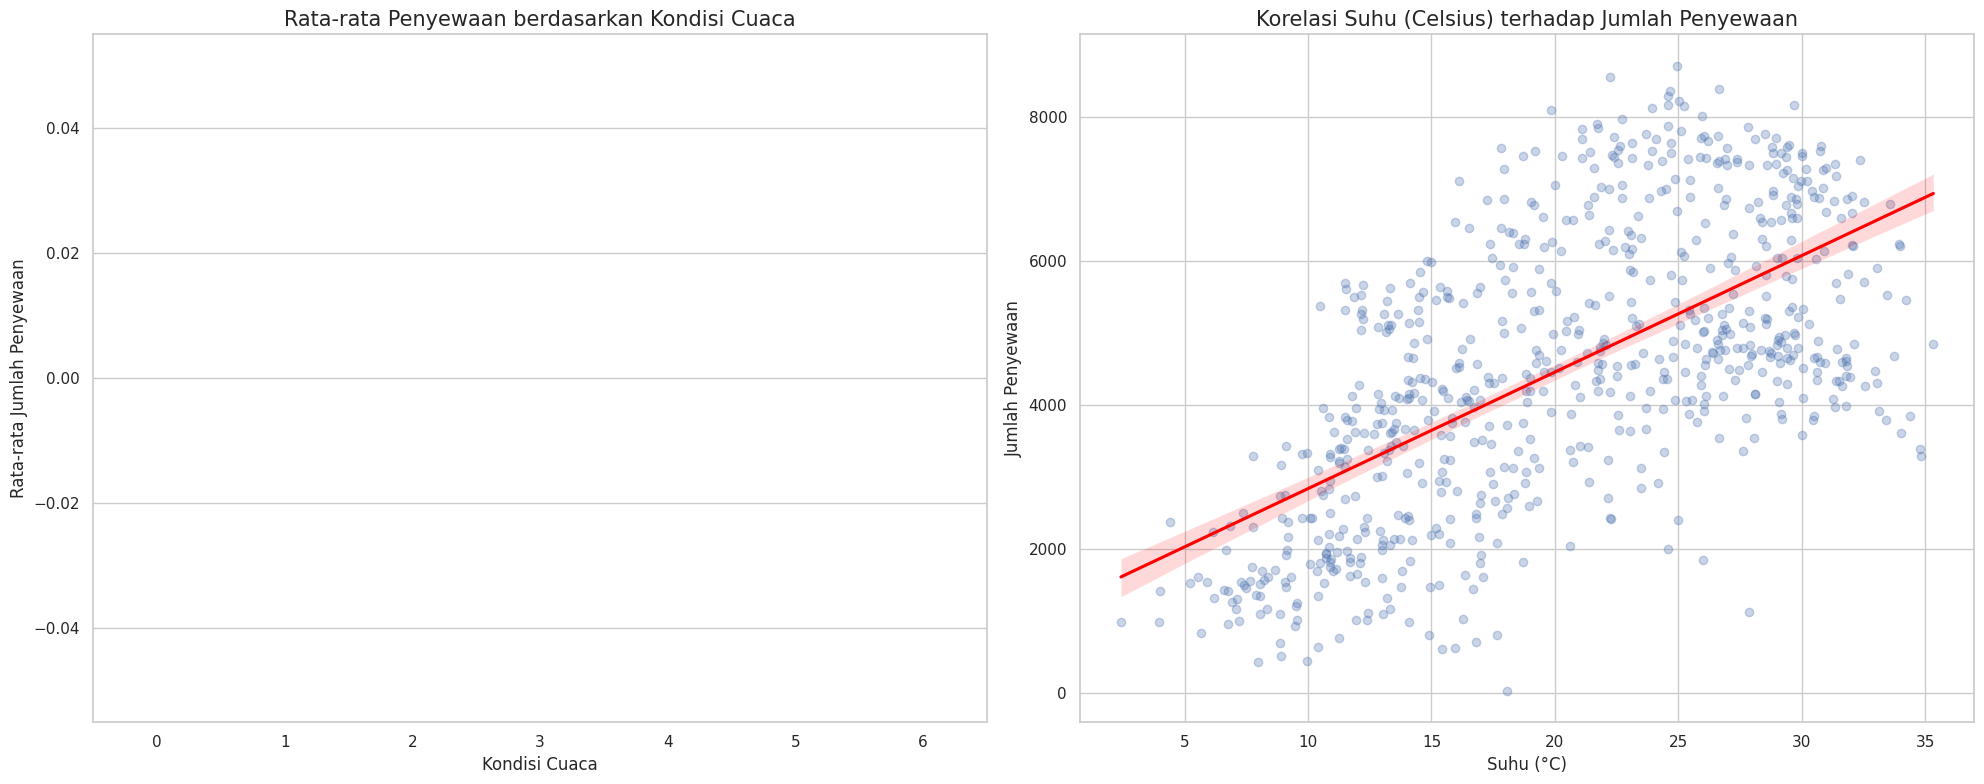

Korelasi Faktor Cuaca terhadap Total Rental (cnt):
cnt             1.000000
atemp_actual    0.631066
temp_actual     0.627494
hum_actual     -0.100659
windspeed      -0.234545
Name: cnt, dtype: float64


In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

day_df['temp_actual'] = day_df['temp'] * 41
day_df['atemp_actual'] = day_df['atemp'] * 50
day_df['hum_actual'] = day_df['hum'] * 100

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))

sns.barplot(
    x='weathersit',
    y='cnt',
    data=day_df,
    ax=ax[0],
    palette='viridis',
    errorbar=None
)
ax[0].set_title('Rata-rata Penyewaan berdasarkan Kondisi Cuaca', fontsize=15)
ax[0].set_xlabel('Kondisi Cuaca', fontsize=12)
ax[0].set_ylabel('Rata-rata Jumlah Penyewaan', fontsize=12)

sns.regplot(
    x='temp_actual',
    y='cnt',
    data=day_df,
    ax=ax[1],
    scatter_kws={'alpha':0.3},
    line_kws={'color':'red'}
)
ax[1].set_title('Korelasi Suhu (Celsius) terhadap Jumlah Penyewaan', fontsize=15)
ax[1].set_xlabel('Suhu (°C)', fontsize=12)
ax[1].set_ylabel('Jumlah Penyewaan', fontsize=12)

plt.tight_layout()
plt.show()

print("Korelasi Faktor Cuaca terhadap Total Rental (cnt):")
correlation = day_df[['temp_actual', 'atemp_actual', 'hum_actual', 'windspeed', 'cnt']].corr()
print(correlation['cnt'].sort_values(ascending=False))

### Pertanyaan 3: Bagaimana perbedaan kontribusi antara pengguna casual dan registered terhadap total penyewaan sepeda pada tahun 2011 hingga 2012, serta segmen mana yang memiliki potensi untuk terus dikembangkan?

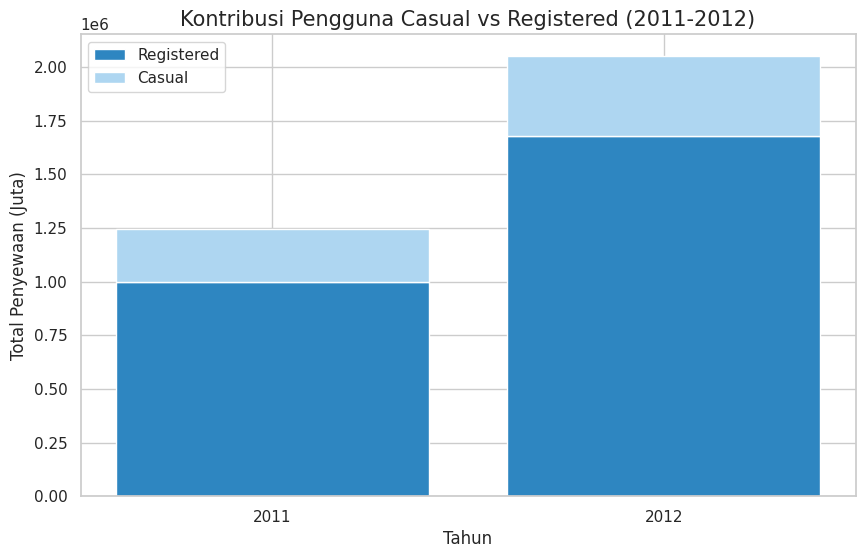

Rata-rata Penyewaan per Hari:


,workingday,casual,registered
0,Hari Libur/Weekend,1371.134199,2959.034632
1,Hari Kerja,606.570000,3978.250000


In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

user_type_year = day_df.groupby('yr')[['casual', 'registered']].sum().reset_index()

plt.figure(figsize=(10, 6))

plt.bar(user_type_year['yr'].astype(str), user_type_year['registered'], label='Registered', color='#2E86C1')
plt.bar(user_type_year['yr'].astype(str), user_type_year['casual'], bottom=user_type_year['registered'], label='Casual', color='#AED6F1')

plt.title('Kontribusi Pengguna Casual vs Registered (2011-2012)', fontsize=15)
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Total Penyewaan (Juta)', fontsize=12)
plt.legend()
plt.show()

user_behavior = day_df.groupby('workingday')[['casual', 'registered']].mean().reset_index()
user_behavior['workingday'] = user_behavior['workingday'].map({0: 'Hari Libur/Weekend', 1: 'Hari Kerja'})

print("Rata-rata Penyewaan per Hari:")
display(user_behavior)

**Insight**:
Pertanyaan 1:
- Tren jumlah penyewaan sepeda menunjukkan pola yang cenderung meningkat hingga mencapai puncaknya pada pertengahan tahun
- Setelah mencapai puncak, terjadi fluktasi jumlah penyewaan yang menunjukkan bahwa permintaan tidak stabil setiap bulan
- Pola kenaikan dan penurunan mengindikasikan adanya pola musiman (seasonality) dalam penggunaan sepeda
- Penurunan signifikan terjadi pada awal dan akhir tahun yang kemungkinan dipengaruhi oleh kondisi cuaca
- Secara keseluruhan, tren menunjukkan adanya pertumbuhan pada periode tertentu, namun tetap dipengaruhi ileh fluktasi musiman

Pertanyaan 2:
- Jumlah penyewaan lebih tinggi pada kondisi cuaca cerah dibandingkan kondisi cuaca buruk
- Suhu memiliki hubungan positif dengan jumlah penyewaan, di mana peningkatan suhu diikuti peningkatan penggunaan sepeda
- Kelembapan menunjukkan kecenderungan hubungan negatif terhadap jumlah penyewaan
- Kondisi cuaca buruk seperti hujan menyebabkan penurunan penyewaan secara signifikan
- Secara keseluruhan, suhu merupakan faktor paling dominan yang memengaruhi permintaan

Pertanyaan 3:
- Pengguna registered memberikan kontribusi terbesar terhadap total penyewaan dibandingkan pengguna casual
- Pengguna casual memiliki kontribusi lebih kecil, namun tetap berperan dalam total penggunaan
- Pengguna registered cenderung menggunakan sepeda secara rutin (kebutuhan harian)
- Pengguna casual cenderung bersifat situasional (rekreasi atau waktu tertentu)
- Segmen casual memiliki potensi untuk dikembangkan menjadi pengguna registered guna meningkatkan penyewaan

## Analisis Lanjutan (Opsional)

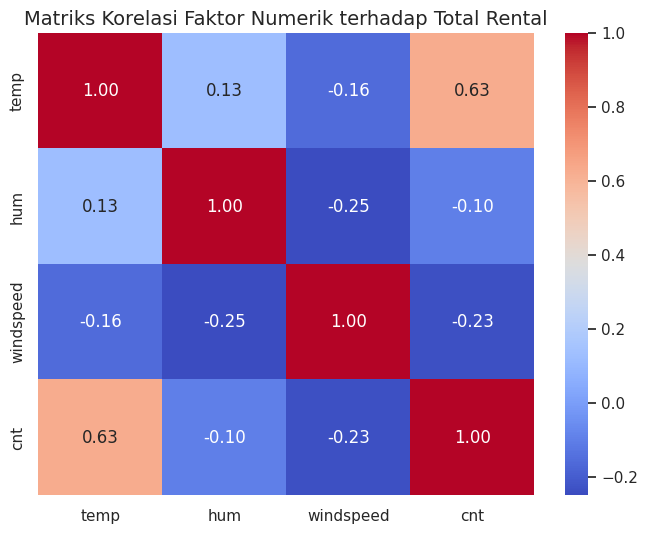

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = day_df[['temp', 'hum', 'windspeed', 'cnt']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriks Korelasi Faktor Numerik terhadap Total Rental', fontsize=14)
plt.show()

## Conclusion & Recommendation

**Conclusion:**
Berdasarkan hasil analisis Bike Sharing Dataset pada tahun 2011 hingga 2012, diperoleh beberapa kesimpulan sebagai berikut:
- Tren penyewaan sepeda menunjukkan pola musiman, dengan peningkatan pada periode tertentu dan penurunan pada awal serta akhir tahun
- Faktor cuaca, khususnya suhu, memiliki pengaruh signifikan terhadap jumlah penyewaan, di mana kondisi cuaca yang baik meningkatkan permintaan
- Pengguna registered memberikan kontribusi terbesar terhadap total penyewaan, menunjukkan bahwa layanan lebih banyak digunakan oleh pelanggan tetap
- Pola penggunaan sepeda dipengaruhi oleh waktu, baik dalam skala bulanan maupun harian, yang menunjukkan adanya periode dengan permintaan tinggi
- Secara keseluruhan, permintaan penyewaan sepeda dipenuhi oleh kombinasi faktor waktu, cuaca, dan karakteristik pengguna.

**Rekomendasi Action Item:**
- Meningkatkan ketersediaan sepeda pada periode dengan permintaan tinggi untuk mengoptimalkan layanan
- Menyusun strategi promosi atau insentif pada kondisi cuaca kurang mendukung guna menjaga stabilitas penggunaan
- Mengembangkan program yang dapat mendorong pengguna casual menjadi pengguna registered
- Mengoptimalkan operasional pada waktu-waktu sibuk untuk meningkatkan efisiensi layanan
- Melakukan evaluasi dan analisis data secara berkala untuk menyesuaikan strategi dengan pola permintaan yang terus berubah

In [80]:
!pip install streamlit
!npm install localtunnel

⠙⠹⠸⠼⠴⠦⠧
up to date, audited 23 packages in 971ms
⠧
⠧3 packages are looking for funding
⠧  run `npm fund` for details
⠧
2 high severity vulnerabilities

To address all issues (including breaking changes), run:
  npm audit fix --force

Run `npm audit` for details.
⠧

In [81]:
%%writefile dashboard.py
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st

st.title
st.write


st.set_page_config(page_title="Bike Sharing Dashboard", layout="wide")

def create_monthly_rent_df(df):
    monthly_rent_df = df.resample(rule='M', on='dteday').agg({
        "cnt": "sum",
        "registered": "sum",
        "casual": "sum"
    }).reset_index()
    monthly_rent_df.rename(columns={"cnt": "total_rentals"}, inplace=True)
    return monthly_rent_df

def create_weather_rent_df(df):
    weather_rent_df = df.groupby(by="weathersit").agg({
        "cnt": "mean"
    }).reset_index()
    return weather_rent_df

all_df = pd.read_csv("day.csv")
all_df['dteday'] = pd.to_datetime(all_df['dteday'])
all_df.sort_values(by="dteday", inplace=True)
all_df.reset_index(inplace=True)

with st.sidebar:
    st.image("https://github.com/dicodingacademy/assets/raw/main/logo.png") # Opsional: Logo

    min_date = all_df["dteday"].min()
    max_date = all_df["dteday"].max()

    start_date, end_date = st.date_input(
        label='Rentang Waktu',
        min_value=min_date,
        max_value=max_date,
        value=[min_date, max_date]
    )

main_df = all_df[(all_df["dteday"] >= str(start_date)) &
                (all_df["dteday"] <= str(end_date))]

monthly_df = create_monthly_rent_df(main_df)
weather_df = create_weather_rent_df(main_df)

st.header('🚲 Bike Sharing Dashboard')

col1, col2, col3 = st.columns(3)
with col1:
    total_rentals = main_df.cnt.sum()
    st.metric("Total Rentals", value=f"{total_rentals:,}")

with col2:
    total_registered = main_df.registered.sum()
    st.metric("Total Registered", value=f"{total_registered:,}")

with col3:
    total_casual = main_df.casual.sum()
    st.metric("Total Casual", value=f"{total_casual:,}")

st.markdown("---")

st.subheader('Monthly Rentals Trend')
fig, ax = plt.subplots(figsize=(16, 8))
ax.plot(
    monthly_df["dteday"],
    monthly_df["total_rentals"],
    marker='o',
    linewidth=2,
    color="#90CAF9"
)
ax.tick_params(axis='y', labelsize=20)
ax.tick_params(axis='x', labelsize=15)
st.pyplot(fig)

col1, col2 = st.columns(2)

with col1:
    st.subheader("Rentals by Weather Condition")
    weather_df['weathersit'] = weather_df['weathersit'].map({
        1: 'Clear', 2: 'Misty', 3: 'Light Rain/Snow', 4: 'Heavy Rain'
    })

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(
        x="weathersit",
        y="cnt",
        data=weather_df,
        palette="viridis",
        ax=ax
    )
    ax.set_title("Average Rentals by Weather", fontsize=15)
    ax.set_ylabel(None)
    ax.set_xlabel(None)
    st.pyplot(fig)

with col2:
    st.subheader("User Contribution Ratio")
    labels = ['Casual', 'Registered']
    sizes = [main_df['casual'].sum(), main_df['registered'].sum()]
    colors = ['#FF9999', '#66B3FF']

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, explode=(0.1, 0))
    ax.axis('equal')
    st.pyplot(fig)

st.caption('Copyright (c) 2026 - Bike Sharing Project Analysis')

Overwriting dashboard.py


In [82]:
!streamlit run dashboard.py & npx localtunnel --port 8501

⠙⠹

your url is: https://all-foxes-doubt.loca.lt
2026-04-28 23:56:03.598 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.74.191.207:8501

  Stopping...
^C


In [83]:
%%writefile requirements.txt
pandas
numpy
matplotlib
seaborn
streamlit

Overwriting requirements.txt
